1. **ISI**
2. **Raster Plot Visualization**
3. **Van Rossum Distance Metric**
4. **KS Metric**
5. **Schreiber Similarity Metric**
6. **Cross Correlogram Metric**
7. **Multi-Scale Correlation Metric**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
import os
import h5py
import helper_functions as hp
import data_loading as dl
gt_data, gt_spikes, sub_data, sub_spikes, cfg, tmap, truth_table, h5_file_path_gt, h5_file_path_sub = dl.get_data()


GT Voltage Data Loading done!
GT Spikes Data Loading done!
SUB Voltage Data Loading done!
SUB Spikes Data Loading done!
Network configuration Loading done!
Trial Map Loading done!
Data Loading done!
GT Voltage Data Loading done!
GT Spikes Data Loading done!
SUB Voltage Data Loading done!
SUB Spikes Data Loading done!
Network configuration Loading done!
Trial Map Loading done!


ISI
GT Model

      neuron pattern        cv  fano                                                              isi
0          E      00       NaN   NaN                                                               []
1          E      11       NaN   NaN                                                               []
2          E      01  0.000000   0.0  [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
3          E      10  0.528920   0.0  [199.0, 601.0, 199.0, 601.0, 199.0, 601.0, 199.0, 601.0, 199.0]
4      Int_A      00       NaN   NaN                                                               []
5      Int_A      11       NaN   NaN                                                               []
6      Int_A      01  0.000000   0.0  [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
7      Int_A      10       NaN   NaN                                                               []
8      Int_B      00       NaN   NaN                                

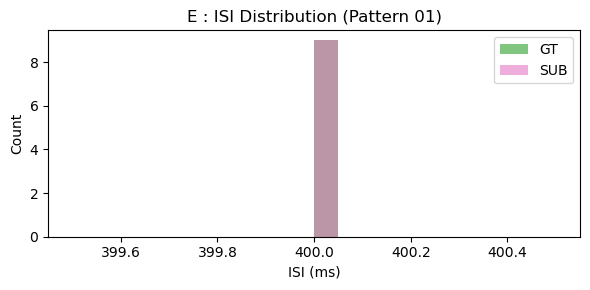


Neuron: E | Pattern: 10
  GT  - CV: 0.5289 | Fano: 0.0
  SUB - CV: 0.5289 | Fano: 0.0
  Wasserstein: 0.0000


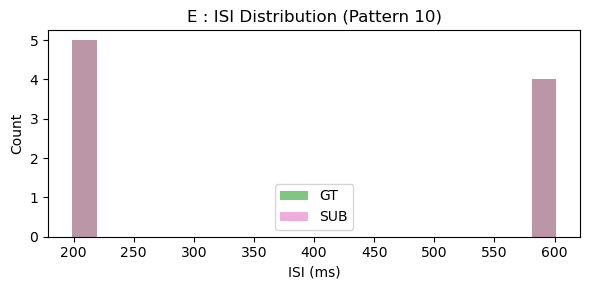

IndexError: index 0 is out of bounds for axis 0 with size 0

In [5]:
#ISI

#Initializing common stuff that gets repeated
spike_cols = list(set(hp.get_spike_cols(cfg, gt_data)) | set(hp.get_spike_cols(cfg, sub_data)))
patterns = tmap["case"].unique().tolist()
for patt in patterns:
    common_ids = tmap[tmap["case"] == patt]["trial_id"].tolist()


try:
    from scipy.stats import wasserstein_distance
except Exception:
    wasserstein_distance = None

rows = []

print("ISI")

def compute_isi_metrics(data_spikes,data, cfg, patterns, tmap):
    rows = []
    for neuron in hp.get_spiking_neurons(cfg, data):
        for p in patterns:
            spike_times = data_spikes[
                (data_spikes["label"] == neuron) & 
                (data_spikes["pattern"] == p)
            ]["spike_time_ms"].to_numpy()
            
            all_reps = tmap[tmap["case"] == p]["rep"].unique()
            counts = data_spikes[
                (data_spikes["label"] == neuron) & 
                (data_spikes["pattern"] == p)
            ].groupby("rep").size().reindex(all_reps, fill_value=0).to_numpy()
            
            isi = np.diff(spike_times)
            
            cv   = np.std(isi) / np.mean(isi) if len(isi) > 0 else None
            fano = np.var(counts) / np.mean(counts) if np.mean(counts) > 0 else None
            
            rows.append({
                "neuron":  neuron,
                "pattern": p,
                "cv":      cv,
                "fano":    fano,
                "isi":     isi  # keep raw ISI for wasserstein + plotting later
            })
    return pd.DataFrame(rows)

gt_isi_stats = compute_isi_metrics(gt_spikes,gt_data,cfg,patterns, tmap)
sub_isi_stats = compute_isi_metrics(gt_spikes,sub_data,cfg,patterns, tmap)
print("GT Model")
print()
print(gt_isi_stats.to_string())
print()
print("SUB Model")
print()
print(sub_isi_stats.to_string())


def plot_isi(gt_isi_df, sub_isi_df):
    for neuron in gt_isi_df["neuron"].unique():
        for p in patterns:
            gt_row = gt_isi_df[(gt_isi_df["neuron"] == neuron) & (gt_isi_df["pattern"] == p)]
            sub_row = sub_isi_df[(sub_isi_df["neuron"] == neuron) & (sub_isi_df["pattern"] == p)]
            
            gt_isi = gt_row["isi"].values[0]
            sub_isi = sub_row["isi"].values[0]
            
            if len(gt_isi) == 0 and len(sub_isi) == 0:
                continue  #Skip that dont give results
            
            if len(gt_isi) > 0 and len(sub_isi) > 0:
                w = wasserstein_distance(gt_isi, sub_isi)
            else:
                w = None

            # print the data
            print(f"\nNeuron: {neuron} | Pattern: {p}")
            print(f"  GT  - CV: {gt_row['cv'].values[0]:.4f} | Fano: {gt_row['fano'].values[0]}")
            print(f"  SUB - CV: {sub_row['cv'].values[0]:.4f} | Fano: {sub_row['fano'].values[0]}")
            print(f"  Wasserstein: {w:.4f}" if w is not None else "  Wasserstein: N/A")
            # plot
            fig, ax = plt.subplots(figsize=(6, 3))
            if len(gt_isi) > 0:
                ax.hist(gt_isi, bins=20, alpha=0.6, label="GT", color="tab:green")
            if len(sub_isi) > 0:
                ax.hist(sub_isi, bins=20, alpha=0.6, label="SUB", color="tab:pink")
            
            ax.set_title(f"{neuron} : ISI Distribution (Pattern {p})")
            ax.set_xlabel("ISI (ms)")
            ax.set_ylabel("Count")
            ax.legend()
            plt.tight_layout()
            plt.show()


plot_isi(gt_isi_stats,sub_isi_stats)

Raster Plot Visualization - Compare GT vs SUB spike patterns


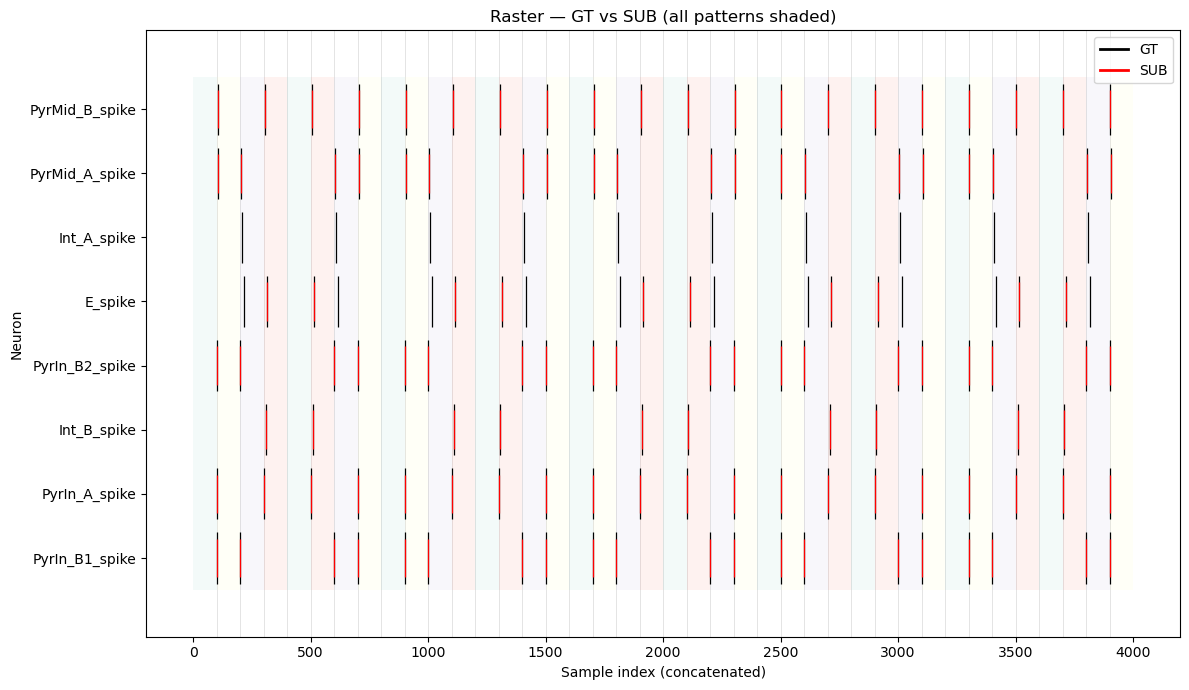

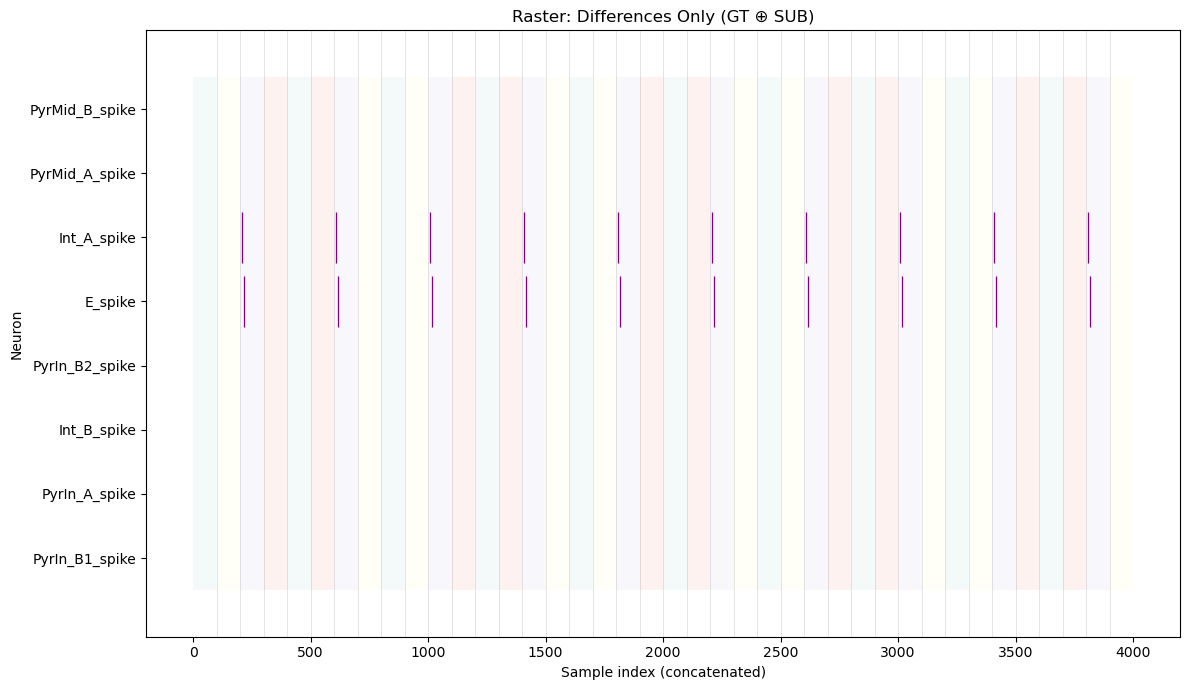


Jaccard similarity per neuron:
  PyrIn_B1_spike     1.000
  PyrIn_A_spike      1.000
  Int_B_spike        1.000
  PyrIn_B2_spike     1.000
  E_spike            0.500
  Int_A_spike        0.000
  PyrMid_A_spike     1.000
  PyrMid_B_spike     1.000
Mean Jaccard: 0.812

Difference counts (GT⊕SUB) per neuron:
  PyrIn_B1_spike     0
  PyrIn_A_spike      0
  Int_B_spike        0
  PyrIn_B2_spike     0
  E_spike            10
  Int_A_spike        10
  PyrMid_A_spike     0
  PyrMid_B_spike     0

Mean Jaccard by pattern:
  pattern 00: 1.000
  pattern 11: 1.000
  pattern 01: 0.750
  pattern 10: 1.000


In [ ]:
#Raster Plot Visualization - Compare GT vs SUB spike patterns

#Initializing common stuff that gets repeated
spike_cols = list(set(hp.get_spike_cols(cfg, gt_data)) | set(hp.get_spike_cols(cfg, sub_data)))
patterns = tmap["case"].unique().tolist()
for patt in patterns:
    common_ids = tmap[tmap["case"] == patt]["trial_id"].tolist()
    
gt_spike_cols  = set(hp.get_spike_cols(cfg, gt_data))
sub_spike_cols = set(hp.get_spike_cols(cfg, sub_data))
meta = hp.load_metadata(h5_file_path_gt)
trial_len = int(meta["trial_len_ms"])
                   

gt  = gt_data.copy()
sub = sub_data.copy()

FILTER_PATTERN = None

# Align lengths
n_rows = min(len(gt), len(sub))
gt = gt.iloc[:n_rows].reset_index(drop=True)
sub = sub.iloc[:n_rows].reset_index(drop=True)

# Extract spike times
gt_times = [np.where(gt[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
sb_times = [np.where(sub[c].to_numpy(dtype=int) == 1)[0] for c in spike_cols]
diff_times = [np.setxor1d(g, s) for g, s in zip(gt_times, sb_times)]

print("Raster Plot Visualization - Compare GT vs SUB spike patterns")

def add_pattern_bands(ax, df, trial_len=100, alpha=0.10):
    """Add colored background bands to indicate input patterns."""
    import matplotlib.cm as cm
    unique_patterns = tmap["case"].unique()
    color_list = cm.Set3.colors[:len(unique_patterns)]
    colors = dict(zip(unique_patterns, [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" for r,g,b in color_list]))
    last_tid = int(df["trial_id"].iloc[-1])
    for tid in range(last_tid + 1):
        block = df[df["trial_id"] == tid]
        if block.empty:
            continue
        start = int(block.index.min())
        pat = str(block["case"].iloc[0])
        rect = Rectangle((start, -0.5), trial_len, len(spike_cols),
                        color=colors.get(pat, "#dddddd"), alpha=alpha, lw=0)
        ax.add_patch(rect)

# Figure 1: Overlay raster (GT and SUB)
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=trial_len, alpha=0.10)

ax.eventplot(gt_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="black")
ax.eventplot(sb_times, orientation="horizontal", linelengths=0.6, linewidths=0.9, colors="red")

ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ttl = "Raster — GT vs SUB" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else " (all patterns shaded)")
ax.set_title(ttl)

# Legend
handles = [Line2D([0],[0], color="black", lw=2, label="GT"),
           Line2D([0],[0], color="red", lw=2, label="SUB")]
ax.legend(handles=handles, loc="upper right")

# Trial separators
total_trials = int(np.ceil(n_rows / trial_len))
for k in range(1, total_trials):
    ax.axvline(k * trial_len, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Figure 2: Differences-only raster
fig, ax = plt.subplots(figsize=(12, 7))

if FILTER_PATTERN is None:
    add_pattern_bands(ax, gt, trial_len=trial_len, alpha=0.10)

ax.eventplot(diff_times, orientation="horizontal", linelengths=0.8, linewidths=0.9, colors="purple")
ax.set_yticks(np.arange(len(spike_cols)))
ax.set_yticklabels(spike_cols)
ax.set_xlabel("Sample index (concatenated)")
ax.set_ylabel("Neuron")
ax.set_title("Raster: Differences Only (GT ⊕ SUB)" + (f" (pattern {FILTER_PATTERN})" if FILTER_PATTERN else ""))

for k in range(1, total_trials):
    ax.axvline(k * trial_len, color="0.85", lw=0.5, zorder=0)

plt.tight_layout()
plt.show()

# Numeric insights
def jaccard(a_idx, b_idx):
    """Compute Jaccard similarity between two spike index arrays."""
    if len(a_idx) == 0 and len(b_idx) == 0:
        return 1.0
    if len(a_idx) == 0 or len(b_idx) == 0:
        return 0.0
    inter = len(np.intersect1d(a_idx, b_idx))
    uni = len(np.union1d(a_idx, b_idx))
    return inter / uni if uni > 0 else 0.0

# Per-neuron Jaccard similarity
J = np.array([jaccard(g, s) for g, s in zip(gt_times, sb_times)], float)
mismatch_counts = {name: int(len(d)) for name, d in zip(spike_cols, diff_times)}
meanJ = float(np.nanmean(J)) if np.isfinite(J).any() else float("nan")

print("\nJaccard similarity per neuron:")
for name, val in zip(spike_cols, J):
    print(f"  {name:<18} {('%.3f'%val) if np.isfinite(val) else 'NA'}")
print(f"Mean Jaccard: {meanJ:.3f}" if np.isfinite(meanJ) else "Mean Jaccard: NA")

print("\nDifference counts (GT⊕SUB) per neuron:")
for k, v in mismatch_counts.items():
    print(f"  {k:<18} {v}")

# Per-pattern Jaccard (when showing all patterns)
if FILTER_PATTERN is None:
    per_pat = {}
    for p in patterns:
        gtp = gt[gt["case"]==p]
        subp = sub[sub["case"]==p]
        n = min(len(gtp), len(subp))
        gtp = gtp.iloc[:n]
        subp = subp.iloc[:n]
        gts = [np.where(gtp[c].to_numpy(int)==1)[0] for c in spike_cols]
        sbs = [np.where(subp[c].to_numpy(int)==1)[0] for c in spike_cols]
        Jp = np.array([jaccard(a,b) for a,b in zip(gts,sbs)], float)
        per_pat[p] = float(np.nanmean(Jp))

    print("\nMean Jaccard by pattern:") 
    for p in patterns:
        print(f"  pattern {p}: {per_pat[p]:.3f}")    
   

In [12]:
# Van Rossum Distance Metric - Spike train comparison with exponential kernel
meta = hp.load_metadata(h5_file_path_gt)
spike_cols = list(set(hp.get_spike_cols(cfg, gt_data)) | set(hp.get_spike_cols(cfg, sub_data)))
patterns = tmap["case"].unique().tolist()
for patt in patterns:
    common_ids = tmap[tmap["case"] == patt]["trial_id"].tolist()
trial_len = int(meta["trial_len_ms"])
MS_PER_SAMPLE = 1000.0 / meta["fs_hz"] if meta["fs_hz"] > 0 else 1.0

print("Van Rossum Distance Metric - Spike train comparison with exponential kernel")

gt_trials_p  = [hp.get_trial(gt_data,  trial_id=i) for i in common_ids]
sub_trials_p = [hp.get_trial(sub_data, trial_id=i) for i in common_ids]

def _spike_times_in_window(df, col, lo_ms, hi_ms):
    if df is None or df.empty or (col not in df.columns):
        return np.empty(0, dtype=float)
    mask = (df["t_in_trial"] >= lo_ms) & (df["t_in_trial"] < hi_ms)
    spike_mask = df[col].to_numpy(dtype=int) == 1
    return df.loc[mask & spike_mask, "t_in_trial"].to_numpy(dtype=float)

def _vr_distance(spike_t_x, spike_t_y, tau_ms):
    """Compute Van Rossum distance with exponential kernel."""
    Nx = spike_t_x.size
    Ny = spike_t_y.size

    if Nx == 0 and Ny == 0:
        return 0.0
    if Nx == 0 or Ny == 0:
        return np.sqrt((Nx + Ny) / (2.0 * tau_ms))

    diffs = np.abs(spike_t_x[:, None] - spike_t_y[None, :])
    sxy = np.exp(-diffs / float(tau_ms)).sum()
    d2 = (Nx + Ny - 2.0 * sxy) / (2.0 * float(tau_ms))
    return float(np.sqrt(max(d2, 0.0)))

def run_vr_metric(tau_ms=10.0, min_trials_per_pattern=1):
    """Compute Van Rossum distance per trial and neuron."""
    if not gt_trials_p or not sub_trials_p:
        empty_cols = ["pattern", "trial_id", "neuron", "VR", "GT_spikes", "SUB_spikes", "tau_ms", "win_lo_ms", "win_hi_ms"]
        return (pd.DataFrame(columns=empty_cols),
                pd.DataFrame(columns=["pattern", "n_trials", "rows", "VR_mean", "VR_median"]),
                pd.DataFrame(columns=["neuron", "rows", "VR_mean", "VR_median"]))

    if not spike_cols:
        empty_cols = ["pattern", "trial_id", "neuron", "VR", "GT_spikes", "SUB_spikes", "tau_ms", "win_lo_ms", "win_hi_ms"]
        return (pd.DataFrame(columns=empty_cols),
                pd.DataFrame(columns=["pattern", "n_trials", "rows", "VR_mean", "VR_median"]),
                pd.DataFrame(columns=["neuron", "rows", "VR_mean", "VR_median"]))

    records = []
    for patt in patterns:
        ids = common_ids
        if not ids or len(ids) < min_trials_per_pattern:
            continue

        for i in ids:
            gt_df = hp.get_trial(gt_data,  trial_id=i)
            sb_df = hp.get_trial(sub_data, trial_id=i)
            lo_ms, hi_ms = 0, trial_len

            for neuron in spike_cols:
                tx = _spike_times_in_window(gt_df, neuron, lo_ms, hi_ms)
                ty = _spike_times_in_window(sb_df, neuron, lo_ms, hi_ms)
                vr = _vr_distance(tx, ty, tau_ms=float(tau_ms))
                records.append({
                    "pattern": patt,
                    "trial_id": i,
                    "neuron": neuron,
                    "VR": vr,
                    "GT_spikes": int(tx.size),
                    "SUB_spikes": int(ty.size),
                    "tau_ms": float(tau_ms),
                    "win_lo_ms": int(lo_ms),
                    "win_hi_ms": int(hi_ms),
                })

    trial_level_df = pd.DataFrame.from_records(records)

    if trial_level_df.empty:
        trial_level_df = pd.DataFrame(columns=["pattern", "trial_id", "neuron", "VR", "GT_spikes", "SUB_spikes", "tau_ms", "win_lo_ms", "win_hi_ms"])

    # Compute summaries
    if not trial_level_df.empty:
        pattern_summary = (
            trial_level_df
            .groupby("pattern", as_index=False)
            .agg(n_trials=("trial_id", lambda x: len(np.unique(x))),
                 rows=("VR", "size"),
                 VR_mean=("VR", "mean"),
                 VR_median=("VR", "median"))
            .sort_values("pattern")
            .reset_index(drop=True)
        )

        neuron_summary = (
            trial_level_df
            .groupby("neuron", as_index=False)
            .agg(rows=("VR", "size"),
                 VR_mean=("VR", "mean"),
                 VR_median=("VR", "median"))
            .sort_values("neuron")
            .reset_index(drop=True)
        )
    else:
        pattern_summary = pd.DataFrame(columns=["pattern", "n_trials", "rows", "VR_mean", "VR_median"])
        neuron_summary = pd.DataFrame(columns=["neuron", "rows", "VR_mean", "VR_median"])

    return trial_level_df, pattern_summary, neuron_summary

# Run metric
vr_trials, vr_by_pattern, vr_by_neuron = run_vr_metric(tau_ms=20.0)

# Print summaries
if not vr_by_pattern.empty:
    print("\n=== Van Rossum — Pattern Summary (τ=20 ms) ===")
    print(vr_by_pattern.to_string(index=False))

if not vr_by_neuron.empty:
    print("\n=== Van Rossum — Neuron Summary (τ=20 ms) ===")
    print(vr_by_neuron.to_string(index=False))

# trial-level table if want the worsts:
# vr_trials.sort_values('VR', ascending=False).head(10)

# Test with a known bad case: spike train shifted by 10ms
spike_t_gt = np.array([10, 50, 100, 150])  # GT spike times
spike_t_shifted = np.array([20, 60, 110, 160])  # Shifted by +10ms

vr_same = _vr_distance(spike_t_gt, spike_t_gt, tau_ms=20.0)
vr_shifted = _vr_distance(spike_t_gt, spike_t_shifted, tau_ms=20.0)

print(f"VR (identical): {vr_same}")
print(f"VR (10ms shift): {vr_shifted}")

# Show trials where spike counts DON'T match (the actual failures)
mismatched = vr_trials[(vr_trials["GT_spikes"] != vr_trials["SUB_spikes"]) & 
                        (vr_trials["pattern"] == "01") &
                        (vr_trials["neuron"] == "E_spike")]

print(f"Pattern 01, E_spike: Mismatched spike count trials")
print(mismatched[["trial_id", "GT_spikes", "SUB_spikes", "VR"]])

# And one specific example: manually check a trial where counts differ
if not mismatched.empty:
    bad_trial_id = mismatched.iloc[0]["trial_id"]
    gt_trial = hp.get_trial(gt_data, trial_id=bad_trial_id)
    sub_trial = hp.get_trial(sub_data, trial_id=bad_trial_id)
    
    print(f"\n=== Pattern 01, trial {bad_trial_id} (GT_E={int(mismatched.iloc[0]['GT_spikes'])}, SUB_E={int(mismatched.iloc[0]['SUB_spikes'])}) ===")
    print(f"GT E spike times: {_spike_times_in_window(gt_trial, 'E_spike', 0, 100)}")
    print(f"SUB E spike times: {_spike_times_in_window(sub_trial, 'E_spike', 0, 100)}")

Van Rossum Distance Metric - Spike train comparison with exponential kernel

=== Van Rossum — Pattern Summary (τ=20 ms) ===
pattern  n_trials  rows  VR_mean  VR_median
     00        10    80      0.0        0.0
     01        10    80      0.0        0.0
     10        10    80      0.0        0.0
     11        10    80      0.0        0.0

=== Van Rossum — Neuron Summary (τ=20 ms) ===
        neuron  rows  VR_mean  VR_median
       E_spike    40      0.0        0.0
   Int_A_spike    40      0.0        0.0
   Int_B_spike    40      0.0        0.0
 PyrIn_A_spike    40      0.0        0.0
PyrIn_B1_spike    40      0.0        0.0
PyrIn_B2_spike    40      0.0        0.0
PyrMid_A_spike    40      0.0        0.0
PyrMid_B_spike    40      0.0        0.0
VR (identical): 0.0
VR (10ms shift): 0.2068950968172679
Pattern 01, E_spike: Mismatched spike count trials
Empty DataFrame
Columns: [trial_id, GT_spikes, SUB_spikes, VR]
Index: []


In [10]:
# Check: what trials/patterns are actually being processed?
print("common_ids:", common_ids)
print("patterns:", patterns)

# Look at the trial-level VR results
print("\n=== Trial-level VR (first 20 rows) ===")
print(vr_trials.head(20))

# Specifically: do we have pattern 01 trials in the data?
pattern_01_vr = vr_trials[vr_trials["pattern"] == "01"]
print(f"\nPattern 01 VR records: {len(pattern_01_vr)}")
print(pattern_01_vr.head(10))

# Manually check one trial that should fail
gt_trial_1 = hp.get_trial(gt_data, trial_id=1)
sub_trial_1 = hp.get_trial(sub_data, trial_id=1)

print(f"\nTrial 1 pattern: {gt_trial_1['case'].iloc[0]}")
print(f"GT E_spike count: {gt_trial_1['E_spike'].sum()}")
print(f"SUB E_spike count: {sub_trial_1['E_spike'].sum()}")

# Manually compute VR for E_spike on trial 1
gt_e_times = _spike_times_in_window(gt_trial_1, "E_spike", 0, 100)
sub_e_times = _spike_times_in_window(sub_trial_1, "E_spike", 0, 100)
manual_vr = _vr_distance(gt_e_times, sub_e_times, tau_ms=20.0)

print(f"GT E spike times: {gt_e_times}")
print(f"SUB E spike times: {sub_e_times}")
print(f"Manual VR for E on trial 1: {manual_vr}")

common_ids: [3, 5, 11, 13, 19, 21, 27, 29, 35, 37]
patterns: ['00', '11', '01', '10']

=== Trial-level VR (first 20 rows) ===
   pattern  trial_id          neuron   VR  GT_spikes  SUB_spikes  tau_ms  \
0       00         3  PyrMid_B_spike  0.0          1           1    20.0   
1       00         3  PyrMid_A_spike  0.0          0           0    20.0   
2       00         3  PyrIn_B1_spike  0.0          0           0    20.0   
3       00         3     Int_B_spike  0.0          1           1    20.0   
4       00         3         E_spike  0.0          1           1    20.0   
5       00         3  PyrIn_B2_spike  0.0          0           0    20.0   
6       00         3   PyrIn_A_spike  0.0          1           1    20.0   
7       00         3     Int_A_spike  0.0          0           0    20.0   
8       00         5  PyrMid_B_spike  0.0          1           1    20.0   
9       00         5  PyrMid_A_spike  0.0          0           0    20.0   
10      00         5  PyrIn_B1_spike  

KS Metric - Kolmogorov-Smirnov Test for Spike Time Distributions
Int_B_spike: KS=0.000, p=1.000


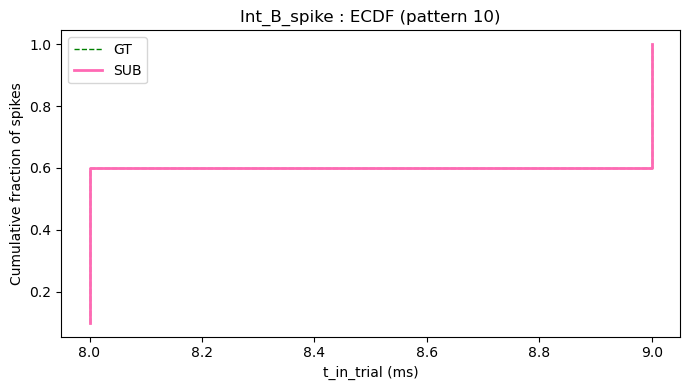

PyrMid_B_spike: KS=0.000, p=1.000


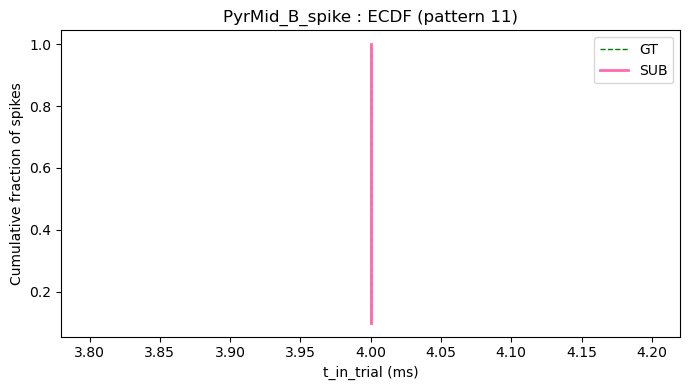

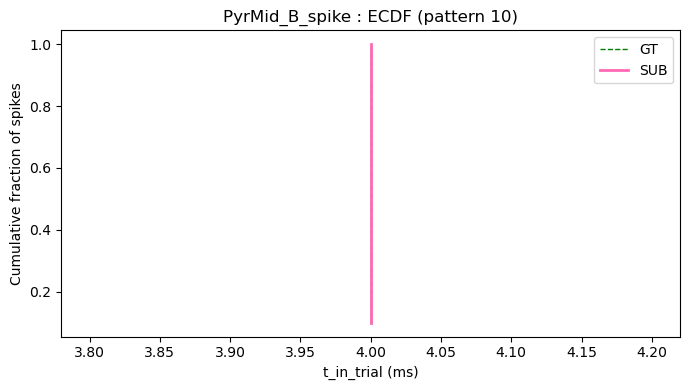

E_spike: KS=0.250, p=0.784


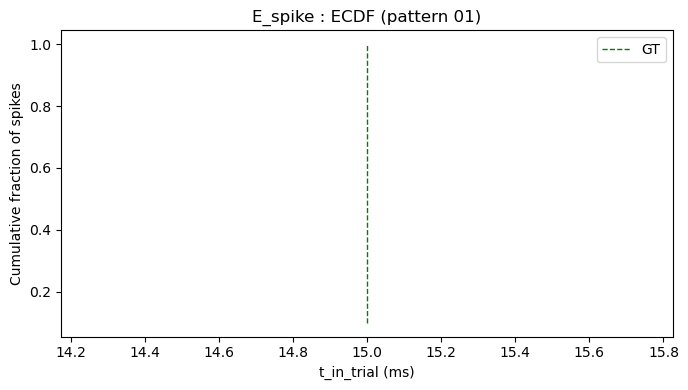

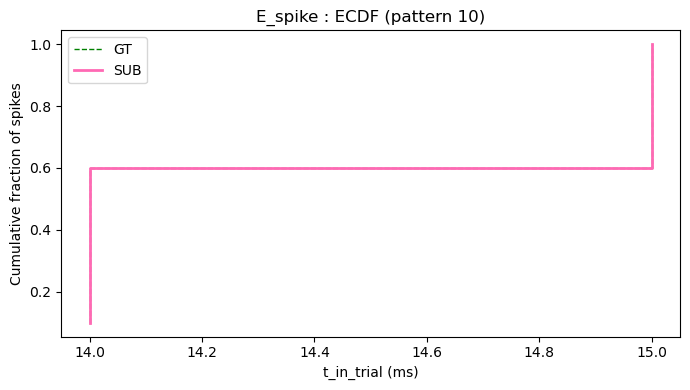

Int_A_spike: not enough spikes


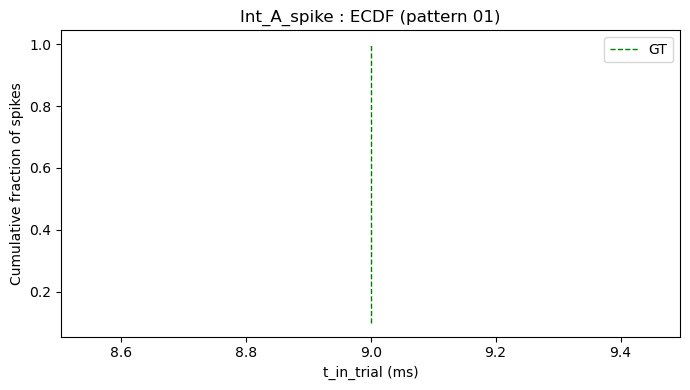

PyrIn_B1_spike: KS=0.000, p=1.000


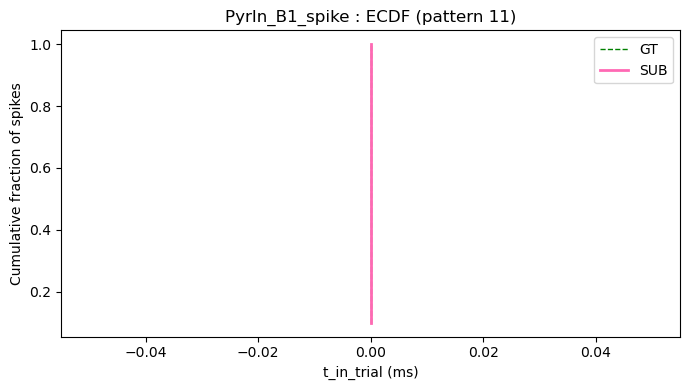

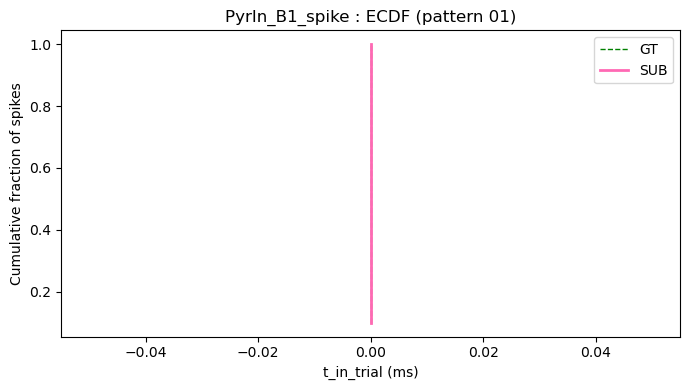

PyrIn_A_spike: KS=0.000, p=1.000


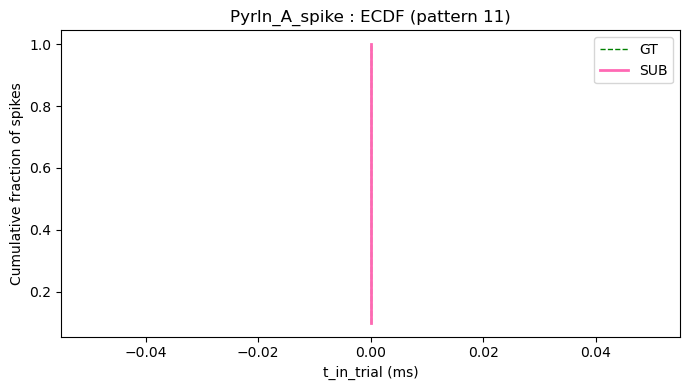

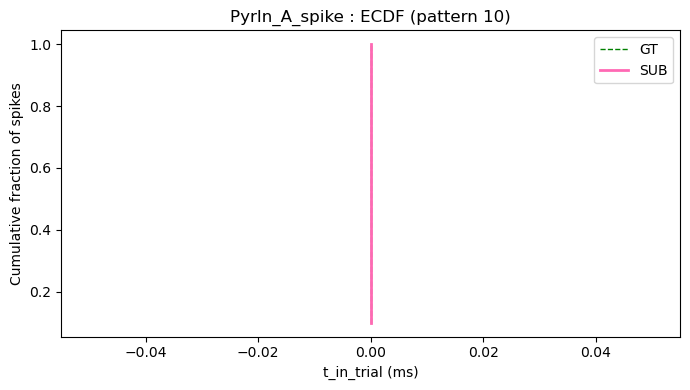

PyrMid_A_spike: KS=0.000, p=1.000


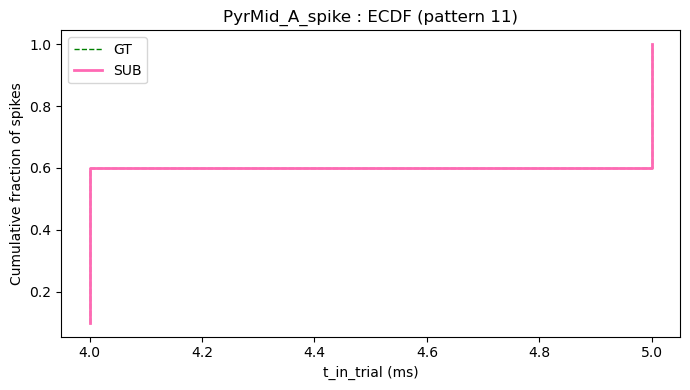

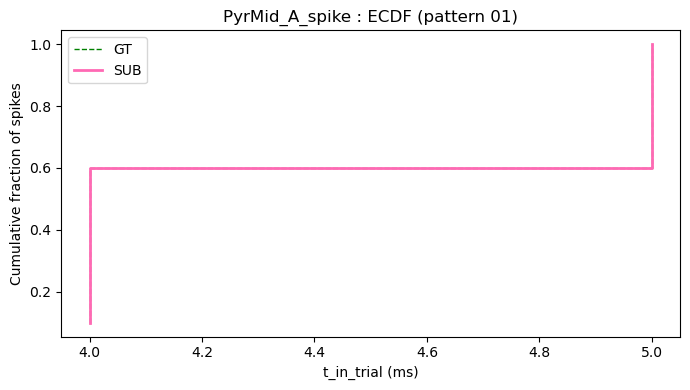

PyrIn_B2_spike: KS=0.000, p=1.000


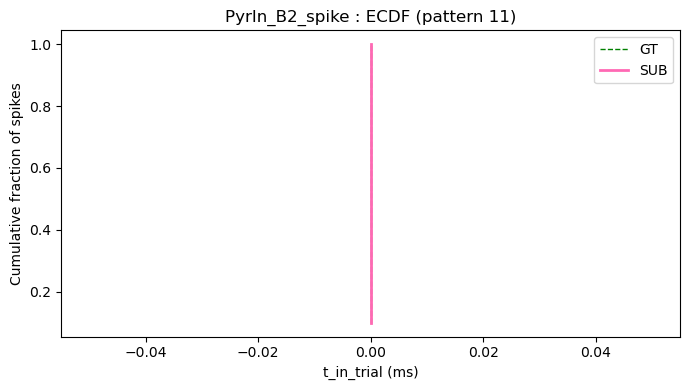

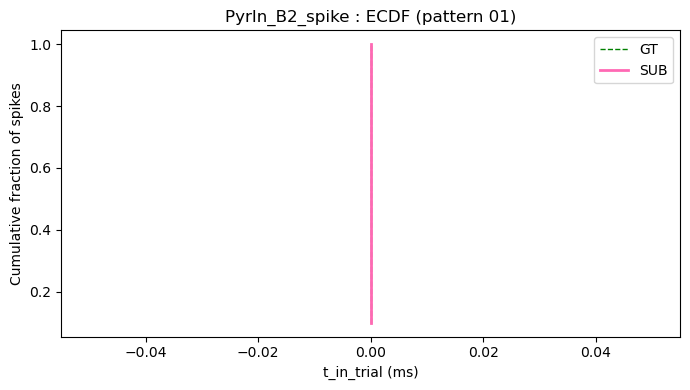

In [7]:
# KS Metric - Kolmogorov-Smirnov Test for Spike Time Distributions
from scipy.stats import ks_2samp

print("KS Metric - Kolmogorov-Smirnov Test for Spike Time Distributions")

def plot_ecdf(gt_times, sub_times, neuron, pattern=None):
    # build ECDFs
    fig, ax = plt.subplots(figsize=(7, 4))
    
    if len(gt_times) > 0:
        gt_sorted  = np.sort(gt_times)
        gt_ecdf  = np.arange(1, len(gt_sorted)  + 1) / len(gt_sorted)
        ax.step(gt_sorted,  gt_ecdf,  label="GT",  color="green", lw=1.0, linestyle="--")

    if len(sub_times) > 0:
        sub_sorted = np.sort(sub_times)
        sub_ecdf = np.arange(1, len(sub_sorted) + 1) / len(sub_sorted)
        ax.step(sub_sorted, sub_ecdf, label="SUB", color="hotpink",   lw=2.0)
    
    ax.set_xlabel("t_in_trial (ms)")
    ax.set_ylabel("Cumulative fraction of spikes")
    title = f"{neuron} : ECDF"
    if pattern:
        title += f" (pattern {pattern})"
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

gt_spike_times = []
sub_spike_times = []
rows_pattern = []
for neuron in spike_cols:
    label = neuron.replace("_spike", "")
    gt_spike_times  = gt_spikes[gt_spikes["label"] == label]["t_in_trial"].to_numpy()
    sub_spike_times = sub_spikes[sub_spikes["label"] == label]["t_in_trial"].to_numpy()

    if len(gt_spike_times) > 0 and len(sub_spike_times) > 0:
        ks_stat, p_val = ks_2samp(gt_spike_times, sub_spike_times)
        print(f"{neuron}: KS={ks_stat:.3f}, p={p_val:.3f}")
    else:
        print(f"{neuron}: not enough spikes")

    for p in patterns:
        gt_times  = gt_spikes[(gt_spikes["label"] == label) & (gt_spikes["pattern"] == p)]["t_in_trial"].to_numpy()
        sub_times = sub_spikes[(sub_spikes["label"] == label) & (sub_spikes["pattern"] == p)]["t_in_trial"].to_numpy()
            
        if len(gt_times) > 0 and len(sub_times) > 0:
            ks_stat, p_val = ks_2samp(gt_times, sub_times)
        else:
            ks_stat, p_val = None, None
            
        rows_pattern.append({
                "neuron":     neuron,
                "pattern":    p,
                "gt_spikes":  len(gt_times),
                "sub_spikes": len(sub_times),
                "ks_stat":    ks_stat,
                "p_value":    p_val
        })

        if len(gt_times) == 0 and len(sub_times) == 0:
            continue  # skip silent patterns
            
        plot_ecdf(gt_times, sub_times, neuron, pattern=p)


Schreiber Similarity Metric - Gaussian-smoothed spike trains

=== Schreiber Similarity — Pattern Summary (σ=10 ms) ===
pattern  n_trials  rows  r_mean  r_median  masked_pct
     00        10    80     1.0       1.0        50.0
     01        10    80     1.0       1.0        50.0
     10        10    80     1.0       1.0        50.0
     11        10    80     1.0       1.0        50.0

=== Schreiber Similarity — Neuron Summary (pooled across patterns) ===
        neuron  rows  r_mean  r_median  both_silent_pct  one_silent_pct
       E_spike    40     1.0       1.0              0.0             0.0
   Int_A_spike    40     NaN       NaN            100.0             0.0
   Int_B_spike    40     1.0       1.0              0.0             0.0
 PyrIn_A_spike    40     1.0       1.0              0.0             0.0
PyrIn_B1_spike    40     NaN       NaN            100.0             0.0
PyrIn_B2_spike    40     NaN       NaN            100.0             0.0
PyrMid_A_spike    40     NaN       

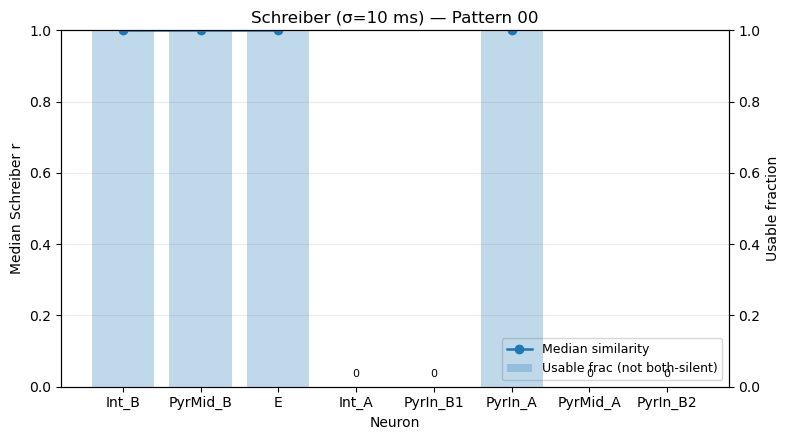

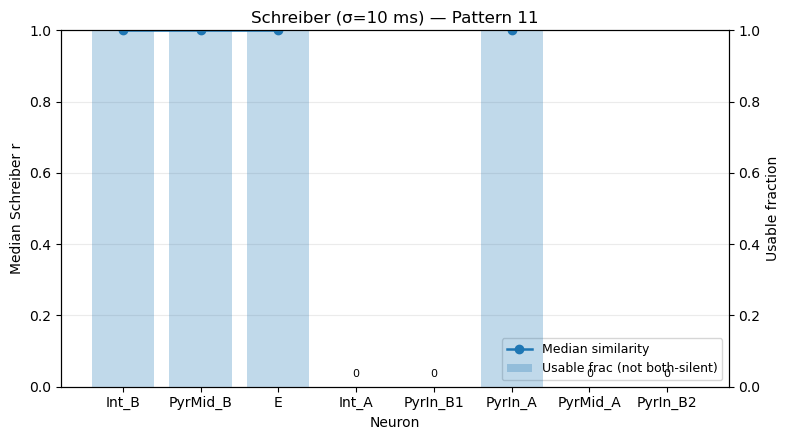

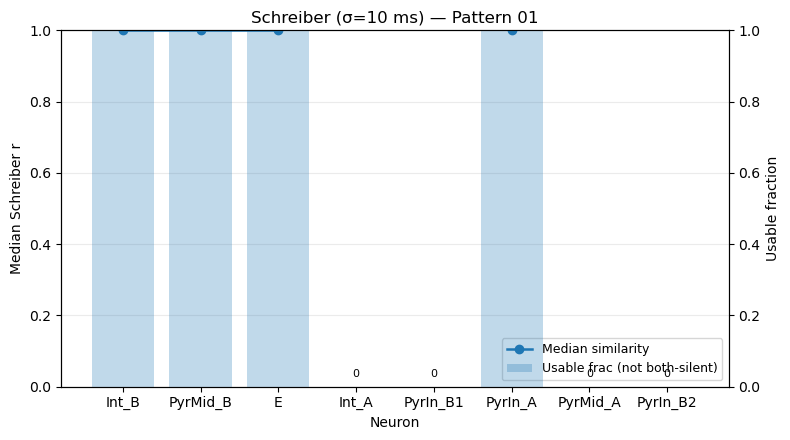

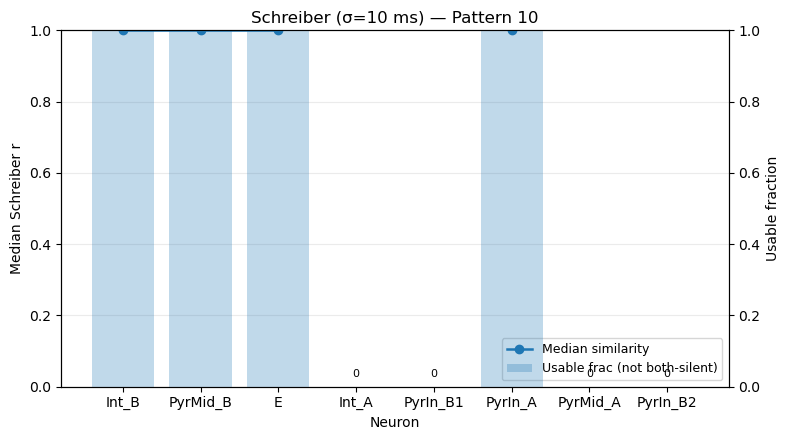

In [9]:
# Schreiber Similarity Metric - Gaussian-smoothed spike trains

print("Schreiber Similarity Metric - Gaussian-smoothed spike trains")

def _binary_segment_in_window(df, col, lo_ms, hi_ms):
    """Extract binary spike segment for window."""
    if df is None or df.empty or (col not in df.columns):
        return np.zeros(0, dtype=np.float32)

    x = df[col].to_numpy(dtype=np.float32)
    n = x.size

    mask = (df["t_in_trial"] >= lo_ms) & (df["t_in_trial"] < hi_ms)
    return df.loc[mask, col].to_numpy(dtype=np.float32)
    
def _gaussian_kernel(sigma_ms, fs_hz):
    """Build Gaussian kernel for smoothing."""
    dt = 1000.0 / float(fs_hz)
    sigma = float(sigma_ms)
    if sigma <= 0:
        return np.array([1.0], dtype=np.float32)
    ksz = max(3, int(round(6.0 * sigma / dt)))
    if ksz % 2 == 0:
        ksz += 1
    half = ksz // 2
    t = (np.arange(ksz) - half) * dt
    g = np.exp(-0.5 * (t / sigma) ** 2).astype(np.float32)
    s = float(g.sum())
    if s > 0:
        g /= s
    return g

def _schreiber_similarity(a_bin, b_bin, kernel):
    """Compute Schreiber similarity between smoothed spike trains."""
    na = int(a_bin.sum() > 0)
    nb = int(b_bin.sum() > 0)
    both_silent = (na == 0 and nb == 0)
    one_silent = ((na == 0) ^ (nb == 0))

    if a_bin.size == 0 or b_bin.size == 0:
        return np.nan, both_silent, one_silent

    ca = np.convolve(a_bin, kernel, mode="same")
    cb = np.convolve(b_bin, kernel, mode="same")
    num = float(np.dot(ca, cb))
    den = float(np.sqrt(np.dot(ca, ca) * np.dot(cb, cb)))
    if den == 0.0:
        return np.nan, both_silent, one_silent
    r = num / den
    r = max(-1.0, min(1.0, r))  # Clamp numerical drift
    return r, both_silent, one_silent

def run_schreiber_metric(sigma_ms=10.0, min_trials_per_pattern=1):
    """Compute Schreiber similarity per trial and neuron."""
    if (not gt_trials_p) or (not sub_trials_p) or (not spike_cols):
        empty_trials = ["pattern", "trial_id", "neuron", "r", "both_silent", "one_silent",
                       "win_lo_ms", "win_hi_ms", "sigma_ms"]
        return (pd.DataFrame(columns=empty_trials),
                pd.DataFrame(columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "masked_pct"]),
                pd.DataFrame(columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"]))

    kernel = _gaussian_kernel(sigma_ms=float(sigma_ms), fs_hz=meta["fs_hz"])

    rows = []
    for patt in patterns:
        ids = common_ids
        if not ids or len(ids) < int(min_trials_per_pattern):
            continue

        for i in ids:
            gt_df = hp.get_trial(gt_data,  trial_id=i)
            sb_df = hp.get_trial(sub_data, trial_id=i)

            lo_ms, hi_ms = 0, trial_len

            for neuron in spike_cols:
                a = _binary_segment_in_window(gt_df, neuron, lo_ms, hi_ms)
                b = _binary_segment_in_window(sb_df, neuron, lo_ms, hi_ms)
                r, both_silent, one_silent = _schreiber_similarity(a, b, kernel)
                rows.append({
                    "pattern": patt,
                    "trial_id": i,
                    "neuron": neuron,
                    "r": float(r) if (r == r) else np.nan,
                    "both_silent": bool(both_silent),
                    "one_silent": bool(one_silent),
                    "win_lo_ms": int(lo_ms),
                    "win_hi_ms": int(hi_ms),
                    "sigma_ms": float(sigma_ms),
                })

    trial_level = pd.DataFrame.from_records(rows)

    # Compute summaries
    if trial_level.empty:
        pattern_summary = pd.DataFrame(columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "masked_pct"])
        neuron_summary = pd.DataFrame(columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"])
        return trial_level, pattern_summary, neuron_summary

    pattern_summary = (
        trial_level
        .groupby("pattern", as_index=False)
        .agg(
            n_trials=("trial_id", lambda x: len(np.unique(x))),
            rows=("r", "size"),
            r_mean=("r", "mean"),
            r_median=("r", "median"),
            masked_pct=("r", lambda x: float(np.mean(np.isnan(x))) * 100.0)
        )
        .sort_values("pattern")
        .reset_index(drop=True)
    )

    neuron_summary = (
        trial_level
        .groupby("neuron", as_index=False)
        .agg(
            rows=("r", "size"),
            r_mean=("r", "mean"),
            r_median=("r", "median"),
            both_silent_pct=("both_silent", lambda x: float(np.mean(x)) * 100.0),
            one_silent_pct=("one_silent", lambda x: float(np.mean(x)) * 100.0),
        )
        .sort_values("neuron")
        .reset_index(drop=True)
    )

    return trial_level, pattern_summary, neuron_summary

def plot_schreiber_per_pattern_lines_bars(trial_level_df, title_prefix="Schreiber (σ=10 ms) — Pattern"):
    """Plot similarity and usable fraction per pattern."""
    if trial_level_df.empty:
        return []
    figs = []

    for patt in patterns:
        dfp = trial_level_df.loc[trial_level_df["pattern"] == patt]
        if dfp.empty:
            continue

        g = (dfp.groupby("neuron", as_index=False)
                .agg(r_median=("r", "median"),
                     usable_frac=("both_silent", lambda x: 1.0 - float(np.mean(x)) if len(x) else np.nan)))

        g["neuron_label"] = g["neuron"].str.replace("_spike", "", regex=False)
        neuron_order = [n for n in spike_cols]
        g = g.set_index("neuron").reindex(neuron_order)
        no_data_mask = g["usable_frac"].isna() & g["r_median"].isna()
        g["usable_frac"] = g["usable_frac"].fillna(0.0)
        
        g = g.reset_index()
        x = np.arange(len(g))
        n_neurons = len(g)
        fig_width = max(8, 0.9 * n_neurons)  # scales with neuron count
        fig, ax1 = plt.subplots(figsize=(fig_width, 4.5))
        ax2 = ax1.twinx()

        # Bars for usable fraction
        bars = ax2.bar(g["neuron_label"], g["usable_frac"].to_numpy(float), alpha=0.28, width=0.8,
                      label="Usable frac (not both-silent)", zorder=1)

        # Mark no-data neurons
        if no_data_mask.any():
            for xi in x[no_data_mask.to_numpy()]:
                ax2.bar(g["neuron_label"].iloc[xi], 0.02,
                       fill=False, hatch="///", edgecolor="k", linewidth=1.0, alpha=0.9,
                       label="_no_data_outline", zorder=3)

        ax2.set_ylim(0.0, 1.0)
        ax2.set_ylabel("Usable fraction")

        # Line for median similarity
        ax1.plot(g["neuron_label"], g["r_median"].to_numpy(float), marker="o", linewidth=1.8,
                label="Median similarity", zorder=4)
        ax1.set_ylim(0.0, 1.0)
        ax1.set_ylabel("Median Schreiber r")
        ax1.set_xlabel("Neuron")
        ax1.set_title(f"{title_prefix} {patt}")
        ax1.grid(alpha=0.25, axis="y")
        plt.xticks(rotation=45, ha="right")

        # Annotate zero bars
        for rect, val in zip(bars, g["usable_frac"].to_numpy(float)):
            if val == 0.0:
                ax2.text(rect.get_x() + rect.get_width()/2, 0.02, "0", ha="center", va="bottom", fontsize=8)

        # Combined legend
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        if no_data_mask.any():
            from matplotlib.patches import Patch
            h2.append(Patch(fill=False, hatch="///", edgecolor="k", linewidth=1.0))
            l2.append("No data (all NaN)")
        ax1.legend(h1+h2, l1+l2, loc="lower right", fontsize=9)

        plt.tight_layout()
        figs.append(fig)
    return figs

# Run Schreiber analysis
sch_trials, sch_by_pattern, sch_by_neuron = run_schreiber_metric(sigma_ms=10.0)

if not sch_by_pattern.empty:
    print("\n=== Schreiber Similarity — Pattern Summary (σ=10 ms) ===")
    print(sch_by_pattern.to_string(index=False))
if not sch_by_neuron.empty:
    print("\n=== Schreiber Similarity — Neuron Summary (pooled across patterns) ===")
    print(sch_by_neuron.to_string(index=False))

figs = plot_schreiber_per_pattern_lines_bars(sch_trials, title_prefix="Schreiber (σ=10 ms) — Pattern")
for f in figs:
    plt.show(f)

In [ ]:
# Cross Correlogram Metric - Binary cross-correlation analysis
from IPython.display import display

MAX_LAG_MS = 15

print("Cross Correlogram Metric - Binary cross-correlation analysis")

def _seg_bin(df, col, lo_idx, hi_idx):
    """Extract binary segment from column."""
    if (col not in df.columns) or lo_idx >= hi_idx:
        return np.zeros(0, dtype=np.int8)
    arr = df[col].to_numpy(int, copy=False)
    hi_idx = min(hi_idx, len(arr))
    return arr[lo_idx:hi_idx].astype(np.int8, copy=False)

def _xcorr_norm(a, b, max_lag):
    """Normalized binary cross-correlation."""
    if a.size == 0 or b.size == 0:
        lags = np.arange(-max_lag, max_lag + 1, dtype=int)
        return lags, np.zeros(lags.size, dtype=float)

    W = int(min(a.size, b.size))
    if W <= 1:
        lags = np.arange(-max_lag, max_lag + 1, dtype=int)
        return lags, np.zeros_like(lags, dtype=float)

    L = int(min(max_lag, W - 1))
    full = np.correlate(a.astype(float), b.astype(float), mode="full")
    l_full = np.arange(-(W - 1), (W - 1) + 1, dtype=int)
    sel = (l_full >= -L) & (l_full <= L)
    lags = l_full[sel]
    counts = full[sel].astype(float)
    eff = (W - np.abs(lags)).astype(float)
    eff[eff <= 0] = np.nan
    cc = counts / eff
    cc = np.where(np.isfinite(cc), cc, 0.0)
    return lags, cc

def _avg_ccg_trials(trials_i, trials_j, meta, col_i, col_j, max_lag):
    """Average CCG across trials."""
    curves = []
    for df_i, df_j, m in zip(trials_i, trials_j, meta):
        lo, hi = 0, trial_len
        ai = _seg_bin(df_i, col_i, lo, hi)
        bj = _seg_bin(df_j, col_j, lo, hi)
        lags, cc = _xcorr_norm(ai, bj, max_lag)
        curves.append(cc)

    if not curves:
        lags = np.arange(-max_lag, max_lag + 1, dtype=int)
        mean_cc = np.zeros_like(lags, dtype=float)
    else:
        mean_cc = np.nanmean(np.vstack(curves), axis=0)
    return lags, mean_cc

def _ccg_matrix_for_pattern(trials_block, meta_block, spike_cols, title, max_lag=MAX_LAG_MS):
    """Create CCG matrix plot for pattern."""
    n = len(spike_cols)
    if n == 0 or not trials_block:
        return None, np.nan

    lags = np.arange(-max_lag, max_lag + 1, dtype=int)
    fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n), sharex=True, sharey=True)
    if n == 1:
        axes = np.array([[axes]])

    zero_vals = []
    for i, ci in enumerate(spike_cols):
        for j, cj in enumerate(spike_cols):
            _, cc = _avg_ccg_trials(trials_block, trials_block, meta_block, ci, cj, max_lag)
            ax = axes[i, j]
            ax.bar(lags, cc, width=1)
            ax.axvline(0, color="red", ls="--", lw=1)
            if i == n - 1:
                ax.set_xlabel(f"Lag (ms)\n{cj}")
            if j == 0:
                ax.set_ylabel(f"{ci}\nCoincidence (norm)")
            if i != j:
                zero_vals.append(cc[max_lag])

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    mean_zero = float(np.nan) if not zero_vals else float(np.nanmean(zero_vals))
    return fig, mean_zero

def _intersect_spike_cols(spike_cols, trials_a, trials_b):
    """Filter spike columns to those present in both datasets."""
    if not trials_a or not trials_b or not spike_cols:
        return []
    cols_a = set(trials_a[0].columns)
    cols_b = set(trials_b[0].columns)
    return [c for c in spike_cols if (c in cols_a and c in cols_b)]

def render_ccg_grids_like_old():
    """Generate CCG matrices and summary statistics."""
    rows, figs = [], []
    for patt in patterns:
        ids = common_ids
        if not ids:
            continue

        fig_gt, mean0_gt = _ccg_matrix_for_pattern(
            gt_trials_p, col, spike_cols,
            title=f"Cross Correlogram — Ground Truth (Concatenated-style) — Pattern {patt}",
            max_lag=MAX_LAG_MS
        )
        fig_sb, mean0_sb = _ccg_matrix_for_pattern(
            sub_trials_p, col, spike_cols,
            title=f"Cross Correlogram — Submission (Concatenated-style) — Pattern {patt}",
            max_lag=MAX_LAG_MS
        )

        if fig_gt is not None:
            figs.append(fig_gt)
        if fig_sb is not None:
            figs.append(fig_sb)

        rows.append(dict(
            Pattern=patt,
            MeanZeroLag_GT=mean0_gt,
            MeanZeroLag_SUB=mean0_sb,
            Delta_SUB_minus_GT=(mean0_sb - mean0_gt) if (np.isfinite(mean0_gt) and np.isfinite(mean0_sb)) else np.nan
        ))

    return pd.DataFrame(rows, columns=["Pattern", "MeanZeroLag_GT", "MeanZeroLag_SUB", "Delta_SUB_minus_GT"]), figs

# Run and display results
ccg_summary_like_old, ccg_figs_like_old = render_ccg_grids_like_old()

# Print summary table
print("\n=== CCG (old-report style) — Mean zero-lag summary ===")
if not ccg_summary_like_old.empty:
    print(ccg_summary_like_old.to_string(index=False))
else:
    print("(no patterns)")

# Display figures
for f in ccg_figs_like_old:
    display(f)
    plt.close(f)


Multi-Scale Correlation Metric - Correlation across time scales


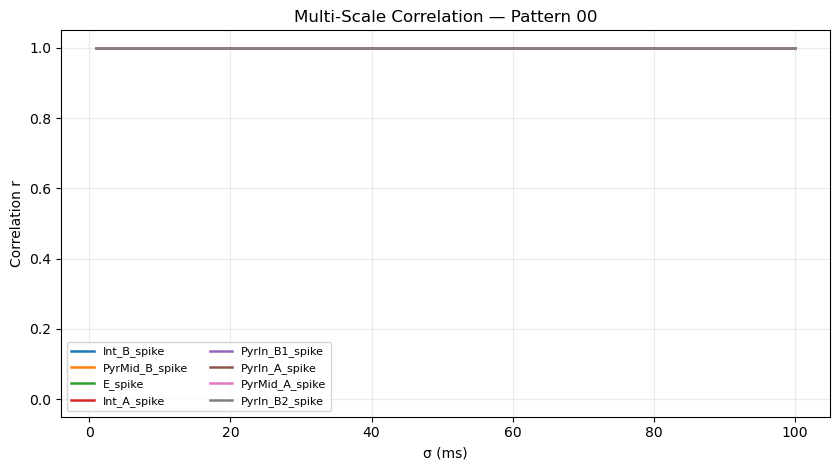

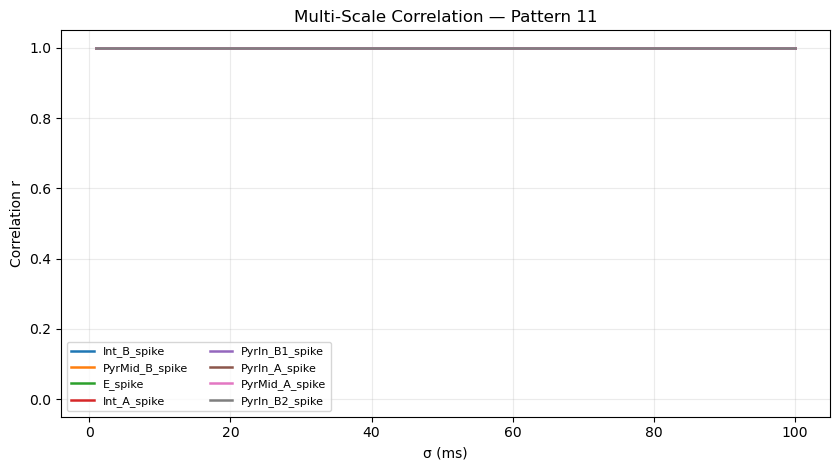

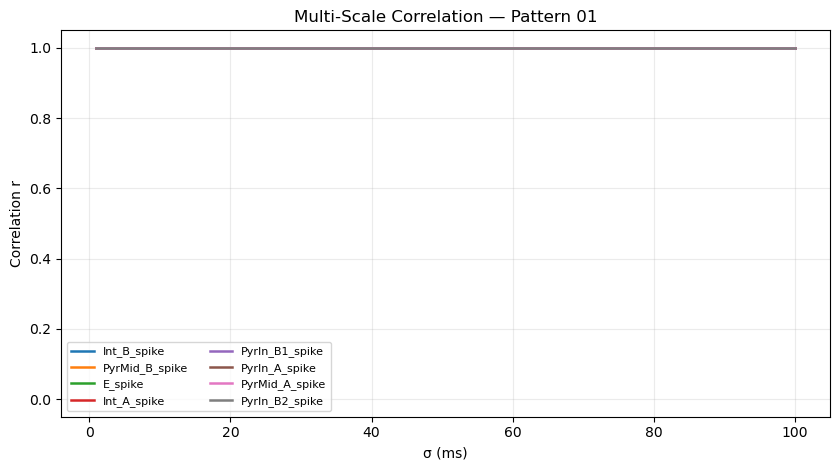

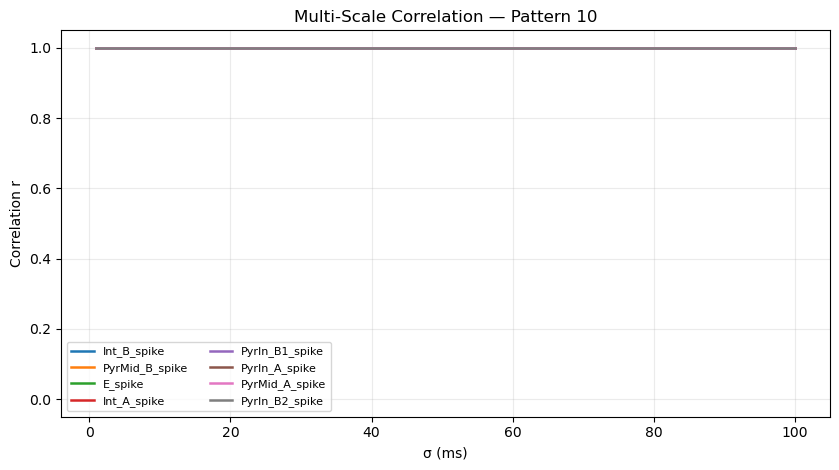


=== Multi-Scale Correlation — Pattern Summary (across trials × neurons × σ) ===
pattern  n_trials  rows  r_mean  r_median  both_silent_pct  one_silent_pct
     00        10  8000     1.0       1.0             50.0             0.0
     11        10  8000     1.0       1.0             50.0             0.0
     01        10  8000     1.0       1.0             50.0             0.0
     10        10  8000     1.0       1.0             50.0             0.0

=== Multi-Scale Correlation — Neuron Summary (pooled across patterns & σ) ===
        neuron  rows  r_mean  r_median  both_silent_pct  one_silent_pct
   Int_B_spike  4000     1.0       1.0              0.0             0.0
PyrMid_B_spike  4000     1.0       1.0              0.0             0.0
       E_spike  4000     1.0       1.0              0.0             0.0
   Int_A_spike  4000     1.0       1.0            100.0             0.0
PyrIn_B1_spike  4000     1.0       1.0            100.0             0.0
 PyrIn_A_spike  4000     1.0     

In [10]:
# Multi-Scale Correlation Metric - Correlation across time scales
import math 
lo_ms = 0
hi_ms = trial_len

MS_PER_SAMPLE = 1000.0 / meta["fs_hz"]

print("Multi-Scale Correlation Metric - Correlation across time scales")

def _window_indices(df, lo_ms, hi_ms):
    n = len(df)
    if n == 0:
        return 0, 0
    lo = int(max(0, lo_ms))
    hi = int(min(n, hi_ms))
    return lo, hi

def _get_bin_window(df, col, lo_idx, hi_idx):
    """Extract binary vector for window."""
    if df is None or df.empty or (col not in df.columns):
        return np.zeros(0, dtype=float)
    arr = df[col].to_numpy(int)
    hi_idx = min(hi_idx, len(arr))
    if lo_idx >= hi_idx:
        return np.zeros(0, dtype=float)
    return arr[lo_idx:hi_idx].astype(float)

def _gauss_kernel_sigma_samp(sig_samp):
    """Create Gaussian kernel."""
    ksz = max(3, int(round(6.0 * sig_samp)))
    if ksz % 2 == 0:
        ksz += 1
    x = np.linspace(-3.0 * sig_samp, 3.0 * sig_samp, ksz)
    g = np.exp(-(x**2) / 2.0)
    g /= g.sum()
    return g

def _pearson_r_safe(a, b):
    """Compute correlation with degenerate case handling."""
    va = float(np.var(a))
    vb = float(np.var(b))
    if va == 0.0 and vb == 0.0:
        return 1.0  # Both constant
    if va == 0.0 or vb == 0.0:
        return 0.0  # One constant
    ca = a - float(np.mean(a))
    cb = b - float(np.mean(b))
    denom = math.sqrt(float(np.sum(ca*ca)) * float(np.sum(cb*cb)))
    if denom == 0.0:
        return 0.0
    return float(np.sum(ca*cb) / denom)

def _msc_curve_for_trial_neuron(gt_df, sb_df, neuron, lo_ms, hi_ms, sigma_vals_ms, dt_ms):
    """Compute correlation curve across scales for single trial/neuron."""
    lo_idx, hi_idx = _window_indices(gt_df, lo_ms, hi_ms)
    a = _get_bin_window(gt_df, neuron, lo_idx, hi_idx)
    b = _get_bin_window(sb_df, neuron, lo_idx, hi_idx)

    # Handle degenerate cases
    sa = int(a.sum())
    sb = int(b.sum())
    if sa == 0 and sb == 0:
        return np.ones_like(sigma_vals_ms, dtype=float), True, False
    if (sa == 0 and sb > 0) or (sa > 0 and sb == 0):
        return np.zeros_like(sigma_vals_ms, dtype=float), False, True

    # Compute correlations at each scale
    r = np.zeros_like(sigma_vals_ms, dtype=float)
    for k, sigma_ms in enumerate(sigma_vals_ms):
        sig_samp = max(1e-6, float(sigma_ms / dt_ms))
        g = _gauss_kernel_sigma_samp(sig_samp)
        ca = np.convolve(a, g, mode="same")
        cb = np.convolve(b, g, mode="same")
        r[k] = _pearson_r_safe(ca, cb)
    return r, False, False

def run_multi_scale_correlation(sigma_ms=(np.arange(1, 101)), per_pattern_plots=True, show=True):
    """Compute multi-scale correlation analysis."""
    if (not gt_trials_p) or (not sub_trials_p) or (not spike_cols):
        print("[msc] Missing trials or spike columns.")
        return (pd.DataFrame(columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"]),
                pd.DataFrame(columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"]),
                {})

    sigma_vals_ms = np.asarray(sigma_ms, dtype=float)
    dt_ms = MS_PER_SAMPLE

    # Storage structures
    per_pattern_per_neuron_curves = {p: {n: [] for n in spike_cols} for p in patterns}
    all_records_neu = {n: [] for n in spike_cols}
    silent_both = {p: {n: 0 for n in spike_cols} for p in patterns}
    silent_one = {p: {n: 0 for n in spike_cols} for p in patterns}
    counts_trials = {p: 0 for p in patterns}
    neuron_tot_trials = {n: 0 for n in spike_cols}
    neuron_both_silent = {n: 0 for n in spike_cols}
    neuron_one_silent = {n: 0 for n in spike_cols}

    # Process each pattern
    for patt in patterns:
        ids = common_ids
        if not ids:
            continue
        counts_trials[patt] = len(ids)

        for i in ids:
            gt_df = hp.get_trial(gt_data,  trial_id=i)
            sb_df = hp.get_trial(sub_data, trial_id=i)

            for neu in spike_cols:
                neuron_tot_trials[neu] += 1
                r_vec, is_both_silent, is_one_silent = _msc_curve_for_trial_neuron(
                    gt_df, sb_df, neu, lo_ms, hi_ms, sigma_vals_ms, dt_ms
                )

                per_pattern_per_neuron_curves[patt][neu].append(r_vec)
                all_records_neu[neu].extend(r_vec.tolist())

                if is_both_silent:
                    silent_both[patt][neu] += 1
                    neuron_both_silent[neu] += 1
                if is_one_silent:
                    silent_one[patt][neu] += 1
                    neuron_one_silent[neu] += 1

    # Generate summaries
    rows_patt = []
    for patt in patterns:
        vals = []
        bs = os_ = 0
        tot_trials_for_pattern = counts_trials[patt] * len(spike_cols) if counts_trials[patt] > 0 else 0
        if counts_trials[patt] > 0:
            for neu in spike_cols:
                curves = per_pattern_per_neuron_curves[patt][neu]
                if curves:
                    vals.extend(np.concatenate(curves).tolist())
                    bs += silent_both[patt][neu]
                    os_ += silent_one[patt][neu]

        if vals:
            arr = np.asarray(vals, dtype=float)
            rows_patt.append({
                "pattern": patt,
                "n_trials": counts_trials[patt],
                "rows": int(arr.size),
                "r_mean": float(np.mean(arr)),
                "r_median": float(np.median(arr)),
                "both_silent_pct": float(100.0 * (bs / tot_trials_for_pattern)) if tot_trials_for_pattern > 0 else np.nan,
                "one_silent_pct": float(100.0 * (os_ / tot_trials_for_pattern)) if tot_trials_for_pattern > 0 else np.nan
            })
    pattern_summary = pd.DataFrame(rows_patt, columns=["pattern", "n_trials", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"])

    rows_neu = []
    for neu in spike_cols:
        vals = np.asarray(all_records_neu[neu], dtype=float)
        tot_trials = neuron_tot_trials[neu]
        if vals.size > 0 and tot_trials > 0:
            rows_neu.append({
                "neuron": neu,
                "rows": int(vals.size),
                "r_mean": float(np.mean(vals)),
                "r_median": float(np.median(vals)),
                "both_silent_pct": float(100.0 * neuron_both_silent[neu] / tot_trials),
                "one_silent_pct": float(100.0 * neuron_one_silent[neu] / tot_trials),
            })
    neuron_summary = pd.DataFrame(rows_neu, columns=["neuron", "rows", "r_mean", "r_median", "both_silent_pct", "one_silent_pct"])

    # Generate plots
    curves_by_pattern = {}
    for patt in patterns:
        ids = common_ids
        if not ids:
            continue

        plt.figure(figsize=(8.5, 4.8))
        for neu in spike_cols:
            curves = per_pattern_per_neuron_curves[patt][neu]
            if not curves:
                continue
            C = np.vstack(curves)
            mean_curve = np.mean(C, axis=0)
            plt.plot(sigma_vals_ms, mean_curve, lw=1.8, label=neu)
            curves_by_pattern.setdefault(patt, {})[neu] = mean_curve

        plt.title(f"Multi-Scale Correlation — Pattern {patt}")
        plt.xlabel("σ (ms)")
        plt.ylabel("Correlation r")
        plt.ylim(-0.05, 1.05)
        plt.legend(loc="best", ncol=2 if len(spike_cols) > 4 else 1, fontsize=8)
        plt.grid(alpha=0.25)
        plt.tight_layout()
        if show:
            plt.show()

    # Print summaries
    if not pattern_summary.empty:
        print("\n=== Multi-Scale Correlation — Pattern Summary (across trials × neurons × σ) ===")
        print(pattern_summary.to_string(index=False))
    else:
        print("\n=== Multi-Scale Correlation — Pattern Summary (across trials × neurons × σ) ===")
        print("(no patterns)")

    if not neuron_summary.empty:
        print("\n=== Multi-Scale Correlation — Neuron Summary (pooled across patterns & σ) ===")
        print(neuron_summary.to_string(index=False))
    else:
        print("\n=== Multi-Scale Correlation — Neuron Summary (pooled across patterns & σ) ===")
        print("(no neurons)")

    return pattern_summary, neuron_summary, curves_by_pattern

# Run analysis
msc_pattern_summary, msc_neuron_summary, msc_curves = run_multi_scale_correlation(
    sigma_ms=np.arange(1, 101),
    per_pattern_plots=True,
    show=True
)